# Notebook 09a: the antisymmetric readout probe (Idea 9, arm 1, zero retrain)

This notebook reifies **arm 1** of research idea 9,
[reflection-equivariant-symmetry-axis](notes/ideas-claude/09-reflection-equivariant-symmetry-axis/README.md).

## Orientation: read this before running anything

**The one question this notebook answers.** Idea 5 (`nb_05a`) asked whether a signed left-minus-right
laterality axis can be read linearly out of the frozen S-JEPA representation, and it returned an
informative null. There is one obvious objection to that null, and this notebook exists to close it:
maybe the problem was never the representation, but the SHAPE OF THE READOUT. A signed quantity ought to
be read by a head that is antisymmetric BY CONSTRUCTION, so that swapping the left and right landmarks
necessarily negates the head's output. Idea 5's probe carried no such guarantee. So we build a head that
does, and we ask whether the null survives.

**What this notebook does NOT do.** It does not retrain, fine-tune, or otherwise alter the encoder. The
encoder is loaded once, frozen, and read. The only thing that changes relative to Idea 5 is the readout's
shape. Training the symmetry INTO the encoder is arm 2, whose real path is the `new_nb_09_00` through
`new_nb_09_03` series; `nb_09b` in this folder is only arm 2's smoke-scale scaffold.

**What the reader is assumed to have.** The completed S-JEPA curriculum checkpoint, the canonical pose
cache, and a reading of `nb_05a`. The constants, preprocessing, model classes, cohort builder, and ridge
probe in sections 1 through 3 and 6 through 8 are reused verbatim from `nb_05a`, so arm 1 is judged on
exactly the same ruler as Idea 5. Only sections 5, 7, 8, 9, and 10 contain anything new.

**The checkpoint and the saved output.** This is a REAL result on real gait data, not a smoke run. The
loaded checkpoint's fingerprint is
`ea59fea055f0230bcf236deb1d1e8bbf08033766e7cd95a98f28210b3042c4e4`, which section 4 prints in full and
section 12 records in the bundle. The source requires the `ea59fea0` prefix and raises an error instead
of continuing if it differs. Every measurement in this notebook belongs to `ea59fea0`, and the guards
for mode, mask whitelist, curriculum completion, condition order, and fingerprint all passed.

**Two mirror facts that must be kept strictly apart.** This is the load-bearing correctness point of the
whole notebook, so it is worth learning before the code starts.

- The **wiring identity is EXACT.** Swapping each left joint's feature with its right partner's AT THE
  HEAD'S INPUT negates the head's output to floating-point precision, giving a slope of exactly -1. This
  is algebra about the head alone, and it says nothing whatsoever about the encoder. Section 5 proves it.
- The **anatomical mirror slope is MEASURED, and it is not -1.** Reflecting the RAW skeleton and running
  it back THROUGH the encoder gives a slope that depends on the encoder, because the encoder mixes tokens
  with attention and adds learned per-joint position codes. Idea 5 measured -0.741 on this same
  checkpoint; section 9 measures -0.223 here. Both are reported as measurements, and neither is ever
  called -1.

**What this notebook produces.** A six-lane control ladder scored against seven hardened preregistered
gates; two figures; and the JSON bundle `idea9_antisymmetric_readout_result.json`. Its verdict is
**ARTIFACT (side-agnostic nuisance control fired)**, which section 10 explains is a WITHDRAWAL of the
claim rather than an answer to it. Section 8 also produces what turned out to be the single most valuable
measurement in the whole Idea 5 and Idea 9 family, and it is a fact about the COHORT rather than about
the encoder: only about 7.5 percent of the signed target's variance lies between source videos.

**Where to go next.** `nb_09c` rehearses the possible futures of these gates and holds the external
multi-view reach scaffold. Arm 2's real result lives in `new_nb_09_00` through `new_nb_09_03`.

**Standing caveats that apply to every number below.** All results are TRANSDUCTIVE: the encoder saw
every evaluation sequence during its own training. The SOURCE VIDEO is the independent unit of evidence,
not the sequence, and there are 18 of them. Folder labels such as stroke and parkinsons are dataset
annotations, not clinical diagnoses. Nothing here is clinical validation and nothing here is unseen-video
performance. See `notes/ideas-claude/_shared_facts.md` for the shared numbers.


## 0. Environment and mode

**Step 1 of 13.**

*What we are about to do.* Resolve the project root, load `.env`, decide whether we can run against the
real artifacts, and print what we bound to.

*Why this comes first.* Every later step depends on which encoder and which cohort we are reading. If the
real checkpoint or the real pose cache is missing, the notebook must not silently produce plausible
numbers from a random encoder and a toy cohort; it falls back to smoke mode and says so loudly. Root
resolution follows notebooks 04 through 06 and `nb_05a` exactly, via `ALEXPOSE_ROOT` or a `.git` plus
`data/gavd` marker, so all of them agree on where the artifacts live. This cell is reused verbatim from
`nb_05a`.

*What to look at in the output.* The line `effective MODE`. In the executed run below it reads `real`,
and both `checkpoint` and `pose cache` report `present=True`. That is what licenses reading the rest of
this notebook as a result rather than as a plumbing check. Also note `ARTIFACT_ROOT`, which points at the
shared `gavd6/work/artifacts` tree rather than at this folder's local one.

*What we may conclude, and what we may not.* We may conclude that the real checkpoint and the real pose
cache were found. We may not yet conclude anything about laterality: nothing has been measured.


In [1]:
from pathlib import Path
import os, sys, math, json, hashlib, copy, warnings

import numpy as np
import pandas as pd

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm"
try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()

REQUESTED_MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if REQUESTED_MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")

TRUTHY = {"1", "true", "yes", "on"}
INCLUDE_AUGMENTED = os.getenv("SJEPA_INCLUDE_AUGMENTED_NORMAL", "1").strip().lower() in TRUTHY
EXPLICIT_CHECKPOINT = os.getenv("SJEPA_INSPECT_CHECKPOINT", "").strip()
CHECKPOINT_NAME = (
    "sjepa_curriculum_final_augmented.pt" if INCLUDE_AUGMENTED else "sjepa_curriculum_final.pt"
)
EXPECTED_FINGERPRINT_PREFIX = "ea59fea0"
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]


def artifact_dir_for(mode):
    return ARTIFACT_ROOT / mode


def checkpoint_path_for(mode):
    if EXPLICIT_CHECKPOINT:
        p = Path(EXPLICIT_CHECKPOINT).expanduser()
        return p if p.is_absolute() else artifact_dir_for(mode) / p
    return artifact_dir_for(mode) / CHECKPOINT_NAME


real_ckpt = checkpoint_path_for("real")
real_poses = artifact_dir_for("real") / "poses"
have_real = REQUESTED_MODE == "real" and real_ckpt.is_file() and real_poses.exists()
MODE = "real" if have_real else "smoke"
if REQUESTED_MODE == "real" and not have_real:
    warnings.warn(
        f"Requested real mode but artifacts are missing "
        f"(checkpoint={real_ckpt.is_file()}, poses={real_poses.exists()}). "
        "Falling back to smoke mode with a synthetic cohort. Smoke numbers are illustrative only."
    )

ARTIFACT_DIR = artifact_dir_for(MODE)
POSE_DIR = ARTIFACT_DIR / "poses"
CHECKPOINT_PATH = checkpoint_path_for(MODE)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

if MODE == "smoke":
    print("SMOKE MODE: hand-authored motions test code paths only. No clinical validity.")
print(f"PROJECT_ROOT      : {PROJECT_ROOT}")
print(f"ARTIFACT_ROOT     : {ARTIFACT_ROOT}")
print(f"requested mode    : {REQUESTED_MODE}")
print(f"effective MODE    : {MODE}")
print(f"checkpoint        : {CHECKPOINT_PATH}  (present={CHECKPOINT_PATH.is_file()})")
print(f"pose cache        : {POSE_DIR}  (present={POSE_DIR.exists()})")

PROJECT_ROOT      : /Users/pmui/dev/alexpose
ARTIFACT_ROOT     : /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts
requested mode    : real
effective MODE    : real
checkpoint        : /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/sjepa_curriculum_final_augmented.pt  (present=True)
pose cache        : /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/poses  (present=True)


## 1. Anatomy constants and the frozen laterality operators (verbatim from nb_05a)

**Step 2 of 13.**

*What we are about to do.* Define the landmark names, the maskable joint whitelist, the left-right pair
lists, the regression target, and the anatomical mirror. Then self-check the target's antisymmetry on raw
coordinates.

*Why we do it now.* Every term in this notebook is built from these definitions, so they must be fixed
before anything is measured, and they must match `nb_05a` character for character or arm 1 would be
judged on a different ruler than Idea 5. Definitions, in the order the code introduces them:

- `MASK_KEYPOINTS` is the 12-landmark maskable whitelist used during training.
- `LEFT_RIGHT_PAIRS` is the six-pair list (shoulders, hips, knees, ankles, heels, foot indices) that both
  the head and the target are built from.
- `FULL_MIRROR_PAIRS` is the complete 16-pair list, matching notebook 05's `geometric_view` flip.
- `signed_left_minus_right(coords)` is the regression target, written `y` from here on. For each of the
  six pairs it takes the left landmark's per-axis standard deviation over time, sums the three axes, does
  the same for the right landmark, and accumulates left minus right. So `y` is a single signed scalar per
  sequence: positive means the left side moved more, negative means the right side moved more.
- `anatomical_mirror(coords)` is the operator `M`. Saying "a reflection" is not enough: `M` does TWO
  things, negating the sideways x coordinate AND swapping each left landmark with its right partner. Only
  both halves together turn a body into its anatomical mirror image.

*Why the self-check matters.* If `y` were not exactly antisymmetric under `M`, then every mirror result
later in the notebook would be measuring a defect in the target rather than a property of the encoder. So
we assert it up front on random coordinates, before any model is involved.

*What to look at in the output.* The pair `original=+1.4555 mirrored=-1.4555`, equal and opposite, and
the `assert` that follows it passing.

*What we may conclude.* The target is exactly antisymmetric under the anatomical mirror AT THE RAW
COORDINATE LEVEL. We may NOT conclude anything about the encoder yet: an encoder is free to destroy this
antisymmetry, and measuring whether it does is the subject of section 9.


In [2]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER", "RIGHT_EYE_INNER", "RIGHT_EYE",
    "RIGHT_EYE_OUTER", "LEFT_EAR", "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST", "RIGHT_WRIST", "LEFT_PINKY",
    "RIGHT_PINKY", "LEFT_INDEX", "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL",
    "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

# The six left-right pairs the head and the signed target are built from.
LEFT_RIGHT_PAIRS = [(11, 12), (23, 24), (25, 26), (27, 28), (29, 30), (31, 32)]

# The FULL 16-pair mirror (matches notebook 05's geometric_view flip): every left/right landmark.
FULL_MIRROR_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10),
    (11, 12), (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]


def signed_left_minus_right(coords):
    '''coords: (T, 33, 3) or (T, 33, >=3). Signed per-side excursion, left minus right.'''
    coords = np.asarray(coords, dtype=np.float64)[..., :3]
    total = 0.0
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        left_excursion = coords[:, left_idx, :].std(axis=0).sum()
        right_excursion = coords[:, right_idx, :].std(axis=0).sum()
        total += left_excursion - right_excursion
    return float(total)


def anatomical_mirror(coords, pairs=FULL_MIRROR_PAIRS):
    '''Negate x and swap each left landmark with its right partner (whole-body reflection).'''
    mirrored = np.asarray(coords, dtype=np.float32).copy()
    mirrored[:, :, 0] = -mirrored[:, :, 0]
    for left_idx, right_idx in pairs:
        mirrored[:, [left_idx, right_idx], :] = mirrored[:, [right_idx, left_idx], :]
    return mirrored


_demo = np.random.randn(20, 33, 3).astype(np.float32)
_orig = signed_left_minus_right(_demo)
_mir = signed_left_minus_right(anatomical_mirror(_demo))
print(f"raw-coordinate self-check:  original={_orig:+.4f}  mirrored={_mir:+.4f}  (should be equal-and-opposite)")
assert abs(_orig + _mir) < 1e-6 * (1 + abs(_orig)), "raw target must be exactly antisymmetric"
print("OK: signed_left_minus_right is antisymmetric on raw coordinates.")

raw-coordinate self-check:  original=+1.4555  mirrored=-1.4555  (should be equal-and-opposite)
OK: signed_left_minus_right is antisymmetric on raw coordinates.


## 2. Preprocessing (reused verbatim from nb_05a)

**Step 3 of 13.**

*What we are about to do.* Define the three-stage preprocessing pipeline: short-gap interpolation of
low-visibility landmarks, pelvis-centering with body-scale normalization, and temporal resize to the
model's frame count.

*Why we do it here, and why verbatim.* The encoder was trained on sequences prepared exactly this way, so
feeding it anything else would measure a distribution shift rather than the representation. Copying the
code from `nb_05a` rather than reimplementing it guarantees the tokens arm 1 caches are the same tokens
Idea 5 scored.

*One subtlety that is easy to get wrong.* The mirror is applied to the RAW coordinate column and only
then is the SAME preprocessing re-run on the mirrored copy. Mirroring after preprocessing would produce
a sequence that is not a valid preprocessed sequence at all (its pelvis centering and body scale would be
inherited from the unmirrored body), and the mirror test in section 9 would then be measuring an
artifact of the pipeline instead of the encoder's behaviour on a genuine reflection.

*What to look at in the output.* Only the confirmation line
`preprocessing helpers ready (interpolate -> center_and_scale -> temporal_resize)`. This cell defines
functions and measures nothing.


In [3]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (np.arange(1, gap + 1, dtype=np.float32) / (gap + 1))[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction)
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    both = left_ok & right_ok
    pelvis[both] = 0.5 * (left_hip[both] + right_hip[both])
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0)
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack([np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])], axis=1)
    return resized.reshape(frames, *array.shape[1:])


def prepare_sequence(raw_sequence, frames):
    '''raw_sequence: [T, 33, 4]. Returns (xyz [frames,33,3], valid [frames,33]).'''
    interpolated, valid = interpolate_low_visibility(raw_sequence)
    scaled = center_and_scale(interpolated)
    xyz = temporal_resize(scaled[..., :3], frames)
    valid_resized = temporal_resize(valid.astype(np.float32), frames) > 0.5
    return xyz.astype(np.float32), valid_resized


print("preprocessing helpers ready (interpolate -> center_and_scale -> temporal_resize).")

preprocessing helpers ready (interpolate -> center_and_scale -> temporal_resize).


## 3. Model classes (reused verbatim so `state_dict` keys match nb_05a and the checkpoint)

**Step 4 of 13.**

*What we are about to do.* Paste the S-JEPA classes (`SkeletonPatchEncoder`, `SkeletonPredictor`,
`SJEPAGait`) inline, exactly as `nb_05a` does.

*Why the classes are pasted rather than imported.* `load_state_dict` matches parameters by key name, so
the class definitions must correspond key for key with the ones that produced the checkpoint. Pasting the
same text is the cheapest way to guarantee that.

*Why we never hardcode dimensions.* The model is always built as `SJEPAGait(**checkpoint["config"])`,
reading whatever the checkpoint stored. Hardcoding, say, `embed_dim=64` would either fail to load or,
worse, load a subset of weights and silently probe a partly random encoder.

*What to look at in the output.* The single line `model classes defined.` If PyTorch were unavailable the
cell would say so and the learned lanes would be skipped, leaving only the raw-coordinate lane and the
target; in the executed run PyTorch is present.


In [4]:
try:
    import torch
    from torch import nn
    HAVE_TORCH = True
except Exception as exc:  # pragma: no cover
    HAVE_TORCH = False
    print(f"PyTorch unavailable ({exc}); learned-encoder lanes will be skipped.")

if HAVE_TORCH:
    class SkeletonPatchEncoder(nn.Module):
        def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                     embed_dim=64, depth=2, heads=4, dropout=0.0):
            super().__init__()
            self.frames, self.joints, self.coordinate_dim = frames, joints, coordinate_dim
            self.segment_length, self.embed_dim = segment_length, embed_dim
            self.segments = frames // segment_length
            self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
            self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
            self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
            layer = nn.TransformerEncoderLayer(
                d_model=embed_dim, nhead=heads, dim_feedforward=embed_dim * 4,
                dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
            self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
            self.norm = nn.LayerNorm(embed_dim)

        def patchify(self, x):
            batch = x.shape[0]
            if x.shape[1:] != (self.frames, self.joints, self.coordinate_dim):
                raise ValueError(f"Expected [B,{self.frames},{self.joints},{self.coordinate_dim}], got {tuple(x.shape)}")
            x = x.reshape(batch, self.segments, self.segment_length, self.joints, self.coordinate_dim)
            x = x.permute(0, 1, 3, 2, 4)
            x = x.flatten(3)
            return x

        def positioned_tokens(self, x):
            tokens = self.patch_embed(self.patchify(x))
            tokens = tokens + self.time_pos[None, :, None, :] + self.joint_pos[None, None, :, :]
            return tokens

        def forward(self, x, keep_mask=None):
            tokens = self.positioned_tokens(x)
            batch = tokens.shape[0]
            flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
            encoded = self.blocks(flat)
            return self.norm(encoded)

    class SkeletonPredictor(nn.Module):
        def __init__(self, segments, joints, encoder_dim=64, predictor_dim=64, depth=2, heads=4, dropout=0.0):
            super().__init__()
            self.segments, self.joints, self.predictor_dim = segments, joints, predictor_dim
            self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
            self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
            nn.init.normal_(self.mask_token, std=0.02)
            self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
            self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
            layer = nn.TransformerEncoderLayer(
                d_model=predictor_dim, nhead=heads, dim_feedforward=predictor_dim * 4,
                dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
            self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
            self.norm = nn.LayerNorm(predictor_dim)
            self.output = nn.Linear(predictor_dim, encoder_dim)

        def forward(self, *args, **kwargs):
            raise NotImplementedError("Predictor is not needed for the frozen probe.")

    class SJEPAGait(nn.Module):
        def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                     embed_dim=64, encoder_depth=2, predictor_depth=2, heads=4):
            super().__init__()
            self.view_encoder = SkeletonPatchEncoder(
                frames, joints, coordinate_dim, segment_length, embed_dim, encoder_depth, heads)
            self.target_encoder = copy.deepcopy(self.view_encoder)
            for parameter in self.target_encoder.parameters():
                parameter.requires_grad_(False)
            segments = frames // segment_length
            self.predictor = SkeletonPredictor(segments, joints, embed_dim, embed_dim, predictor_depth, heads)
            self.register_buffer("target_center", torch.zeros(embed_dim))

    print("model classes defined.")

model classes defined.


## 4. Bind to one checkpoint and build the untrained-encoder floor

**Step 5 of 13.**

*What we are about to do.* Load the real checkpoint under the same guards `nb_05a` uses, construct the
model from its stored config, and separately construct a FRESH RANDOMLY INITIALISED model of identical
architecture. This cell is reused verbatim from `nb_05a`.

*Why the second, random model exists.* It becomes lane C, the untrained-encoder FLOOR. A random network
still projects the coordinates and can preserve some left-versus-right structure by accident. Lane C asks
whether representation training added useful information beyond that untrained projection. Comparing two
encoders with the same shape and the same readout isolates the contribution of training. Building lane C
before anything is measured keeps the control preregistered rather than fitted after the fact.

*What the guards check, in order.* That the checkpoint's mode matches, that its mask whitelist is the
12-point set, that the progressive curriculum actually completed, and that the conditions were seen in
the registered order. Any mismatch raises.

*What to look at in the output.*

- The fingerprint prefix `ea59fea055f0`, which is the authoritative lineage recorded in section 12.
- The config: `embed_dim 96`, `encoder_depth 4`, `frames 64`, and `segment_length 4`, giving
  `SEGMENTS = 16`.
- The confirmation that the untrained floor model was built from a different seed.
- The `enable_nested_tensor` warnings from PyTorch, which are benign and occur because
  `norm_first=True`.

The saved output below now names the same `ea59fea0` lineage as the source guard.

*What we may conclude.* The real checkpoint is the current `ea59fea0` baseline, and lane C is a matched
untrained floor.


In [5]:
CHECKPOINT = None
FINGERPRINT = "smoke-random"
if HAVE_TORCH and MODE == "real":
    CHECKPOINT = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
    if CHECKPOINT.get("mode") != MODE:
        raise ValueError(f"Checkpoint mode {CHECKPOINT.get('mode')} does not match {MODE}.")
    if CHECKPOINT.get("mask_keypoints") != MASK_KEYPOINTS:
        raise ValueError("Checkpoint mask whitelist does not match the 12-point set.")
    if not CHECKPOINT.get("curriculum_complete", False):
        raise ValueError("Checkpoint is not a completed progressive curriculum final.")
    if CHECKPOINT.get("conditions_seen") != CONDITIONS:
        raise ValueError(f"Unexpected curriculum order: {CHECKPOINT.get('conditions_seen')}.")
    FINGERPRINT = str(CHECKPOINT.get("dataset_fingerprint", ""))
    if not FINGERPRINT.startswith(EXPECTED_FINGERPRINT_PREFIX):
        raise ValueError(
            f"Fingerprint {FINGERPRINT[:12]} does not start with {EXPECTED_FINGERPRINT_PREFIX}."
        )
    config = CHECKPOINT["config"]
    model = SJEPAGait(**config)
    model.load_state_dict(CHECKPOINT["model_state"])
    model.eval()
    FRAMES = config["frames"]
    SEGMENT_LENGTH = config["segment_length"]
    EMBED_DIM = config["embed_dim"]
    print(f"Loaded {EXPECTED_FINGERPRINT_PREFIX} lineage. fingerprint prefix: {FINGERPRINT[:12]}  config: {config}")
elif HAVE_TORCH:
    config = {"frames": 32, "joints": 33, "coordinate_dim": 3, "segment_length": 4,
              "embed_dim": 32, "encoder_depth": 1, "predictor_depth": 1, "heads": 4}
    torch.manual_seed(RANDOM_SEED)
    model = SJEPAGait(**config).eval()
    FRAMES, SEGMENT_LENGTH, EMBED_DIM = config["frames"], config["segment_length"], config["embed_dim"]
    print(f"Smoke encoder built (untrained). config: {config}")
else:
    FRAMES, SEGMENT_LENGTH, EMBED_DIM = 64, 4, 96  # documentary defaults; no encoder available.
    model = None

floor_model = None
if HAVE_TORCH:
    torch.manual_seed(RANDOM_SEED + 1)
    floor_model = SJEPAGait(**config).eval()
    print("Untrained-encoder floor model built (fresh random init).")

SEGMENTS = FRAMES // SEGMENT_LENGTH
print(f"FRAMES={FRAMES}  SEGMENT_LENGTH={SEGMENT_LENGTH}  SEGMENTS={SEGMENTS}  EMBED_DIM={EMBED_DIM}")

Loaded ea59fea0 lineage. fingerprint prefix: ea59fea055f0  config: {'frames': 64, 'joints': 33, 'coordinate_dim': 3, 'segment_length': 4, 'embed_dim': 96, 'encoder_depth': 4, 'predictor_depth': 2, 'heads': 4}
Untrained-encoder floor model built (fresh random init).
FRAMES=64  SEGMENT_LENGTH=4  SEGMENTS=16  EMBED_DIM=96


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_96510/3289459315.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_96510/3289459315.py:59: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


## 5. The antisymmetric head, and the exact wiring guarantee

**Step 6 of 13. This is the one piece of new machinery in the notebook, and the reason arm 1 exists.**

*What we are about to build.* A readout head whose output must negate when left and right are exchanged.
It computes

`s = sum over the six pairs k of ( f(L_k) - f(R_k) )`

where `L_k` and `R_k` are the time-averaged token features of pair `k`'s left and right landmarks, and
`f` is a SINGLE SHARED per-joint map, `f = Linear(EMBED_DIM, 32) -> GELU -> Linear(32, m)`. The output
`s` is therefore an `m`-dimensional signed vector, with `m = 4` by default (`HEAD_OUT_DIM`).

*Why the head is shaped this way. Two design points, both load-bearing.*

1. **Difference only, with no `left + right` term.** A term `f(L_k) + f(R_k)` does not change at all when
   left and right are exchanged, so it is mirror-INVARIANT. Including it would dilute the guaranteed sign
   flip with a channel that carries no side information. This is precisely where arm 1 departs from Idea
   5: Idea 5's `laterality_feature_from_tokens` emitted both the difference AND the sum. Arm 1's head is
   a NEW pure-difference head, not a reuse of Idea 5's feature.
2. **`f` is fixed, seeded, and shared, so arm 1 stays truly zero-retrain.** The antisymmetry guarantee is
   algebraic and holds for ANY `f`, trained or not, because `f` is applied identically to both sides.
   That means a fixed random `f` is a perfectly legitimate antisymmetric readout. The only thing fit later
   is Idea 5's ridge probe on top of the head's output, in fold, exactly as for every other lane. No
   gradient ever reaches the encoder in this notebook.

*The wiring guarantee, stated before we test it.* If we swap each left joint's feature with its right
partner's at the head's INPUT, then every term `f(L_k) - f(R_k)` becomes `f(R_k) - f(L_k)`, so the whole
sum negates exactly. The cell below verifies this numerically on random tokens.

*Why we verify something we just proved on paper.* Because the point of the verification is not the
algebra, it is ruling out our OWN implementation mistakes. If the head were subtly miswired, for instance
by indexing the pair list wrongly, then a negative outcome later could be blamed on the bug rather than
on the representation, and the whole experiment would be uninterpretable. Establishing the wiring first
means that whatever happens later, it is not this.

*What to look at in the output.* Two lines. `max|s_swap + s| = 0.000e+00`, the residual of the identity,
which is exactly zero here. And `swap-vs-original slope = -1.000000`, which section 12 records to full
precision as **-1.0000000000000002**, that is -1 to the last representable bit.

*What we may conclude, and what we may NOT.* We may conclude that the head is antisymmetric by
construction, so any later failure is NOT an implementation bug in the head. We may NOT conclude that the
ENCODER respects the mirror: this slope of -1 concerns the head's own inputs only. The encoder's
behaviour under a genuine anatomical reflection is a separate, measured quantity, and section 9 finds it
to be -0.223, nowhere near -1. Conflating these two numbers is the single easiest way to misread this
notebook.


In [6]:
HEAD_OUT_DIM = int(os.getenv("IDEA9_HEAD_OUT_DIM", "4"))  # m: width of the signed vector s

antisym_head = None
if HAVE_TORCH:
    class AntisymmetricHead(nn.Module):
        '''s = sum_k ( f(L_k) - f(R_k) ) over LEFT_RIGHT_PAIRS, with f SHARED across all joints/sides.
        Difference only; no symmetric (l + r) term. Antisymmetric under an input swap by construction.'''
        def __init__(self, embed_dim, out_dim=4, hidden=32, pairs=LEFT_RIGHT_PAIRS):
            super().__init__()
            self.pairs = list(pairs)
            self.f = nn.Sequential(
                nn.Linear(embed_dim, hidden), nn.GELU(), nn.Linear(hidden, out_dim))

        def per_joint_feature(self, tokens):
            '''tokens: [B, SEGMENTS, 33, D] -> per-joint time-mean [B, 33, D] (matches nb_05a).'''
            return tokens.mean(dim=1)

        def forward(self, tokens):
            '''tokens: [B, SEGMENTS, 33, D]. Returns s: [B, out_dim].'''
            pj = self.per_joint_feature(tokens)  # [B, 33, D]
            s = 0.0
            for left_idx, right_idx in self.pairs:
                s = s + (self.f(pj[:, left_idx, :]) - self.f(pj[:, right_idx, :]))
            return s

        def forward_capacity_matched(self, tokens):
            '''Capacity-matched CONTROL readout. Uses the EXACT SAME shared f, width, and per-pair
            aggregation as forward(), and differs ONLY by adding the symmetric (l + r) path next to the
            antisymmetric (l - r) path. Returns [B, 2*out_dim] = concat( sum_k (f(L)-f(R)), sum_k (f(L)+f(R)) ).
            This is NOT antisymmetric: the (l + r) half is mirror-INVARIANT. Comparing A' against this
            control isolates the antisymmetry constraint from the head's nonlinearity, init, and pair info,
            because those are held identical; only the symmetric path is added.'''
            pj = self.per_joint_feature(tokens)  # [B, 33, D]
            diff = 0.0
            summ = 0.0
            for left_idx, right_idx in self.pairs:
                diff = diff + (self.f(pj[:, left_idx, :]) - self.f(pj[:, right_idx, :]))
                summ = summ + (self.f(pj[:, left_idx, :]) + self.f(pj[:, right_idx, :]))
            return torch.cat([diff, summ], dim=-1)

        @torch.no_grad()
        def forward_swapped(self, tokens):
            '''Swap each left joint's feature with its right partner's AT THE HEAD INPUT, then run f.
            This is the exact wiring check; it must return -forward(tokens).'''
            pj = self.per_joint_feature(tokens)  # [B, 33, D]
            pj_sw = pj.clone()
            for left_idx, right_idx in self.pairs:
                pj_sw[:, left_idx, :] = pj[:, right_idx, :]
                pj_sw[:, right_idx, :] = pj[:, left_idx, :]
            s = 0.0
            for left_idx, right_idx in self.pairs:
                s = s + (self.f(pj_sw[:, left_idx, :]) - self.f(pj_sw[:, right_idx, :]))
            return s

    torch.manual_seed(RANDOM_SEED + 7)
    antisym_head = AntisymmetricHead(EMBED_DIM, out_dim=HEAD_OUT_DIM).eval()
    for p in antisym_head.parameters():
        p.requires_grad_(False)  # Arm 1 is zero-retrain: f is fixed.

    # ---- Wiring guarantee proof: forward_swapped(x) == -forward(x) to tolerance ----
    _rng = np.random.default_rng(RANDOM_SEED)
    _tok = torch.tensor(_rng.standard_normal((8, SEGMENTS, 33, EMBED_DIM)), dtype=torch.float32)
    with torch.no_grad():
        _s = antisym_head(_tok)
        _s_sw = antisym_head.forward_swapped(_tok)
    _max_abs = float((_s_sw + _s).abs().max())
    _scale = float(_s.abs().max()) + 1e-9
    # Per-sample slope of swapped vs original (should be exactly -1).
    _slope = float(np.polyfit(_s.reshape(-1).numpy(), _s_sw.reshape(-1).numpy(), 1)[0])
    print(f"WIRING CHECK  max|s_swap + s| = {_max_abs:.3e}   (relative {_max_abs/_scale:.3e})")
    print(f"WIRING CHECK  swap-vs-original slope = {_slope:+.6f}   (must be -1.000000)")
    WIRING_IDENTITY_OK = bool(_max_abs <= 1e-5 * _scale and abs(_slope + 1.0) <= 1e-4)
    assert WIRING_IDENTITY_OK, "Antisymmetric head failed the exact wiring guarantee; fix the head."
    print("OK: head is antisymmetric by construction under the input swap (slope exactly -1).")
else:
    WIRING_IDENTITY_OK = None
    _slope = None
    print("No torch: antisymmetric head and wiring proof skipped.")

WIRING CHECK  max|s_swap + s| = 0.000e+00   (relative 0.000e+00)
WIRING CHECK  swap-vs-original slope = -1.000000   (must be -1.000000)
OK: head is antisymmetric by construction under the input swap (slope exactly -1).


## 6. Build the cohort with provenance and source-video tags (verbatim from nb_05a)

**Step 7 of 13.**

*What we are about to do.* Read the pose cache into records that keep the raw `[T, 33, 4]` sequence plus
four pieces of metadata: `video_id`, `condition`, `sequence_id`, and a structural `provenance` tag.

*Why the `video_id` tag is the most important column here.* Sequences from the same source video are not
independent observations: they share the subject, the camera, the lighting, and the pose-estimator's
idiosyncrasies. If folds were split by sequence, a probe could score well by recognising the video rather
than by reading laterality. So `video_id` is carried through to section 8, where it defines
source-disjoint folds. This is what makes the SOURCE VIDEO, not the sequence, the independent unit of
evidence.

*What to look at in the output.* `real cohort: 96 sequences from 18 source videos`, and the per-condition
counts: cerebralpalsy 16, myopathic 47, normal 12, parkinsons 9, stroke 12. Two observations to carry
forward. First, 18 sources is a small number, and it is the number that ends up binding this entire
experiment (section 8). Second, the cohort is heavily unbalanced toward myopathic, which is why section 8
pools laterality across all conditions instead of reporting per-class results.

*A note on smoke mode, which did not run here.* The `else` branch builds synthetic fixtures with a
planted, sign-alternating lateral lean, so that in smoke mode the probe has a real sign to find and the
mirror a real sign to flip. That planted lean is a plumbing signal and not physiology. It is not used in
the executed run below, which reads the real cache.


In [7]:
FRAMES_SMOKE = 64


def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Code-path fixture copied from nb_05a (NOT a disease simulation).'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {11: (0.42, 0.28), 12: (0.58, 0.28), 23: (0.45, 0.52), 24: (0.55, 0.52),
            25: (0.44, 0.70), 26: (0.56, 0.70), 27: (0.43, 0.89), 28: (0.57, 0.89),
            29: (0.42, 0.92), 30: (0.58, 0.92), 31: (0.39, 0.94), 32: (0.61, 0.94)}
    for joint, (x, y_) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y_
    amplitude, lift = 0.045, 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


SMOKE_LEAN_MAGNITUDE = {"stroke": 1.0, "cerebralpalsy": 0.8, "parkinsons": 0.5,
                        "myopathic": 0.0, "normal": 0.0}


def plant_signed_lean(seq, sign, magnitude, seed):
    if magnitude == 0.0 or sign == 0:
        return seq
    rng = np.random.default_rng(seed)
    out = seq.copy()
    phase = np.linspace(0.0, 4.0 * np.pi, len(seq), endpoint=False)
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        gain = 0.03 * magnitude * sign * rng.uniform(0.8, 1.2)
        out[:, left_idx, 0] += gain * np.sin(phase)
        out[:, right_idx, 0] -= gain * np.sin(phase)
    return out


def synthesize_smoke_cohort(clips_per_source=3, frames=FRAMES_SMOKE):
    records = []
    counter = 0
    for condition in CONDITIONS:
        for source in range(2):
            sign = 1 if source == 0 else -1
            mag = SMOKE_LEAN_MAGNITUDE[condition]
            for clip in range(clips_per_source):
                base = synthetic_gait_sequence(condition=condition, frames=frames, seed=RANDOM_SEED + counter)
                seq = plant_signed_lean(base, sign, mag, seed=RANDOM_SEED + 1000 + counter)
                records.append({
                    "condition": condition,
                    "sequence_id": f"smoke_{condition}_{source}_{clip:02d}",
                    "video_id": f"smoke_source_{condition}_{source}",
                    "raw": seq, "provenance": "canonical",
                })
                counter += 1
    return records


def pose_records_from_cache(pose_dir, conditions):
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        if not folder.exists():
            continue
        for path in sorted(folder.glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "raw": sequence,
                "provenance": "canonical",
            })
    return records


if MODE == "real":
    records = pose_records_from_cache(POSE_DIR, CONDITIONS)
    print(f"real cohort: {len(records)} sequences from {len({r['video_id'] for r in records})} source videos")
else:
    records = synthesize_smoke_cohort()
    print(f"smoke cohort: {len(records)} synthetic sequences from {len({r['video_id'] for r in records})} sources")

meta = pd.DataFrame([{k: r[k] for k in ("condition", "sequence_id", "video_id", "provenance")} for r in records])
print(meta.groupby(["condition"]).size().to_string())
if len({r["video_id"] for r in records}) < 2:
    raise ValueError("Need at least two source videos for a source-disjoint split.")

real cohort: 96 sequences from 18 source videos
condition
cerebralpalsy    16
myopathic        47
normal           12
parkinsons        9
stroke           12


## 7. Compute the frozen target `y` and cache the six lanes

**Step 8 of 13. This is the control ladder, and it is the heart of the experiment.**

*What we are about to do.* Compute the target `y` once, then compute six different feature sets ("lanes")
over the same 96 sequences. Each lane exists to close one specific escape route. Because a control's
number is meaningless to a reader who does not yet know what it rules out, each lane is described below
by its JOB, and the numbers come later in step 9.

- **`y`, the target.** `signed_left_minus_right` on the preprocessed coordinates, frozen before any fit.

- **Lane A_prime, the TREATMENT.** The `m`-dimensional antisymmetric head output `s` on the frozen
  `ea59fea0` target-encoder tokens. This is the thing arm 1 is actually testing.

- **Lane Ac_capacity_matched, the ATTRIBUTION control.** Escape route it closes: "any head with that much
  machinery would have scored the same, so the win has nothing to do with antisymmetry." Ac uses the
  EXACT SAME fixed `f`, the same width, and the same per-pair aggregation as A_prime, and differs in
  exactly one respect: it also concatenates the symmetric `l + r` path, giving a `2m`-dimensional
  feature. Because the `l + r` half is mirror-INVARIANT, Ac is NOT antisymmetric. So a gap between
  A_prime and Ac is attributable to the antisymmetry CONSTRAINT rather than to nonlinearity,
  initialisation, dimensionality, or pair information, all of which are held identical.

- **Lane B_raw_null, the descriptive CEILING.** Handcrafted per-pair signed excursion differences taken
  straight from the coordinates, with no network at all. Escape route it closes: it shows the target is
  recoverable in principle. But note carefully that it is NEARLY CIRCULAR, because it fits raw
  standard-deviation differences to a target built from those same standard-deviation differences. It is
  therefore descriptive only and is explicitly NOT a gate.

- **Lane C_floor, the untrained-encoder FLOOR.** The SAME antisymmetric head applied to the random-init
  encoder from section 4. Escape route it closes: "the head and the probe did all the work and the
  trained encoder contributed nothing."

- **Lane D_standard, the COMPARABILITY lane.** Idea 5's `laterality_feature_from_tokens`, which includes
  the symmetric `l + r` half, on the same frozen tokens. This is literally Idea 5's lane A carried
  forward, so that Idea 5 and arm 1 can be compared on one axis inside a single table instead of across
  two notebooks.

- **Lane E_pooled, the SIDE-BLIND nuisance control, and the lane that ends up deciding this notebook.**
  Escape route it closes, which is the deepest one: "the score is not about sides at all, it is about
  overall magnitude or acquisition nuisance." Building this control correctly is subtle. Global mean and
  standard deviation pooling over tokens is NOT by itself side-blind, because the encoder adds learned
  per-joint position codes, so each token stays conditioned on its landmark slot even after pooling. So
  lane E is SYMMETRIZED over the anatomical mirror, `E(x) = 0.5 * (pool(enc(x)) + pool(enc(Mx)))`. Since
  `M` is an involution, this makes `E(x) == E(Mx)` identically. Lane E is therefore MATHEMATICALLY BLIND
  to left and right: it cannot distinguish a body from its reflection even in principle. Only a control
  with that property can validly withdraw a signed claim, which is why the code asserts the invariance
  numerically before the lane is trusted.

*Why we also cache the mirrored features.* The mirrored tokens `tokA_mir` (the head run on the
anatomically mirrored input, through the encoder) serve two purposes: the measured anatomical-mirror slope
in step 10, and the symmetrization that makes lane E side-blind.

*What to look at in the output.* Three lines, in order of importance.

1. `Lane E anatomical-invariance check: max|E(x) - E(Mx)| = 0.000e+00`. Exactly zero. Lane E really is
   side-blind, so it is admissible as the nuisance control.
2. The feature widths, which show the lanes are honestly different objects rather than reskins of one
   another: A_prime 4, Ac 8, B 18, C 4, D 1152, E 192.
3. `y stats: mean=+0.0447 std=3.1315 n=96`. The target is roughly centred, so a mean-only predictor would
   score near zero R-squared and negative R-squared values mean "worse than predicting the mean".

*What we may conclude.* Nothing about laterality yet. All we have established is that the ladder is built
correctly and that its most important control is provably blind to the thing under test.


In [8]:
def encoder_tokens(enc_model, xyz_batch):
    '''xyz_batch: [B, FRAMES, 33, 3] float32. Returns [B, SEGMENTS, 33, EMBED_DIM] numpy.'''
    with torch.no_grad():
        x = torch.tensor(xyz_batch, dtype=torch.float32)
        tok = enc_model.target_encoder(x).reshape(len(xyz_batch), SEGMENTS, 33, EMBED_DIM)
    return tok.cpu().numpy()


def antisym_feature_from_tokens(tokens_np):
    '''tokens_np: [SEGMENTS, 33, D] -> the m-dim antisymmetric head output s (difference only).'''
    with torch.no_grad():
        t = torch.tensor(tokens_np[None, ...], dtype=torch.float32)
        s = antisym_head(t)
    return s[0].cpu().numpy()


def capacity_matched_feature_from_tokens(tokens_np):
    '''Lane Ac: the capacity-matched control readout on the SAME head/f. Returns the 2*m-dim
    concat(difference, sum). Identical machinery to A' except for the added symmetric (l + r) path, so an
    A'-vs-Ac gap is attributable to the antisymmetry constraint rather than head architecture.'''
    with torch.no_grad():
        t = torch.tensor(tokens_np[None, ...], dtype=torch.float32)
        s = antisym_head.forward_capacity_matched(t)
    return s[0].cpu().numpy()


def laterality_feature_from_tokens(tokens):
    '''Item 05's Lane A feature: per L/R pair, time-mean of LEFT, RIGHT, their difference AND sum.
    Includes the symmetric (l + r) half by design. Reused verbatim as Lane D (standard comparator).'''
    feats = []
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        l = tokens[:, left_idx, :].mean(axis=0)
        r = tokens[:, right_idx, :].mean(axis=0)
        feats.append(l - r)
        feats.append(l + r)
    return np.concatenate(feats)


def raw_null_feature(xyz):
    '''Lane B handcrafted signed features: per-pair signed excursion difference on the three axes.'''
    feats = []
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        l = xyz[:, left_idx, :].std(axis=0)
        r = xyz[:, right_idx, :].std(axis=0)
        feats.append(l - r)
    return np.concatenate(feats)


def pooled_nuisance_raw(tokens):
    '''Global mean and std over ALL joint-time tokens. Permutation-invariant over the OUTPUT-TOKEN order,
    but NOT invariant to an anatomical side swap: the encoder adds learned per-joint position codes, so a
    token's value stays conditioned on its landmark slot even after global pooling. Do not use this raw
    version as the side-agnostic control; symmetrize it (below) first.'''
    flat = tokens.reshape(-1, tokens.shape[-1])
    return np.concatenate([flat.mean(axis=0), flat.std(axis=0)])


def pooled_nuisance_feature(tokens, tokens_mirror):
    '''Lane E (side-agnostic control), made invariant under the FULL anatomical swap by averaging the
    pooled feature over a sample AND its anatomically mirrored counterpart (both run THROUGH the encoder):
        E(x) = 0.5 * ( pool(enc(x)) + pool(enc(Mx)) ).
    Because M is an involution (mirroring twice is the identity) and enc(Mx)'s mirror is enc(x), this E is
    identical for a sample and its mirror by construction: E(x) == E(Mx). A side-agnostic control MUST be
    unable to tell a body from its reflection; only then does a significant E genuinely mean the signed
    axis leaked into a nuisance channel. We assert the invariance numerically before using it as a gate.'''
    return 0.5 * (pooled_nuisance_raw(tokens) + pooled_nuisance_raw(tokens_mirror))


prepared = [prepare_sequence(r["raw"], FRAMES) for r in records]
xyz_all = np.stack([p[0] for p in prepared]).astype(np.float32)
y = np.array([signed_left_minus_right(x) for x in xyz_all], dtype=np.float64)
B_raw = np.stack([raw_null_feature(x) for x in xyz_all])

prepared_mir = [prepare_sequence(anatomical_mirror(r["raw"]), FRAMES) for r in records]
xyz_mir = np.stack([p[0] for p in prepared_mir]).astype(np.float32)

if HAVE_TORCH:
    def batched_tokens(enc, arr, bs=16):
        out = []
        for i in range(0, len(arr), bs):
            out.append(encoder_tokens(enc, arr[i:i + bs]))
        return np.concatenate(out)

    tokA = batched_tokens(model, xyz_all)
    tokA_mir = batched_tokens(model, xyz_mir)
    tokC = batched_tokens(floor_model, xyz_all)

    Aprime = np.stack([antisym_feature_from_tokens(t) for t in tokA])       # Lane A' (new head)
    Aprime_mir = np.stack([antisym_feature_from_tokens(t) for t in tokA_mir])
    C_floor = np.stack([antisym_feature_from_tokens(t) for t in tokC])      # Lane C (head on floor)
    D_std = np.stack([laterality_feature_from_tokens(t) for t in tokA])     # Lane D (item 05 Lane A)
    # Lane Ac: capacity-matched control head. SAME fixed f, SAME width, SAME aggregation as A', differing
    # ONLY by adding the symmetric (l + r) path alongside the difference. Isolates the antisymmetry
    # constraint from nonlinearity/init/dimensionality/pair-info confounds (Codex high finding).
    Ac_match = np.stack([capacity_matched_feature_from_tokens(t) for t in tokA])
    # Lane E: side-agnostic nuisance control, symmetrized over the anatomical mirror so E(x) == E(Mx).
    E_pooled = np.stack([pooled_nuisance_feature(t, tm) for t, tm in zip(tokA, tokA_mir)])
    # ---- invariance self-check: the control MUST be blind to a body-vs-mirror flip ----
    E_pooled_mir = np.stack([pooled_nuisance_feature(tm, t) for t, tm in zip(tokA, tokA_mir)])
    _e_gap = float(np.abs(E_pooled - E_pooled_mir).max())
    print(f"Lane E anatomical-invariance check: max|E(x) - E(Mx)| = {_e_gap:.3e}  (must be ~0)")
    assert _e_gap < 1e-5, "Lane E must be invariant under the anatomical swap; symmetrization failed."
    E_INVARIANT_OK = True
    print(f"feature widths -> A':{Aprime.shape[1]}  Ac:{Ac_match.shape[1]}  B:{B_raw.shape[1]}  "
          f"C:{C_floor.shape[1]}  D:{D_std.shape[1]}  E:{E_pooled.shape[1]}")
else:
    Aprime = Aprime_mir = C_floor = D_std = E_pooled = Ac_match = None
    E_INVARIANT_OK = None
    print("No torch: only Lane B (raw null) and the target y are available.")

print(f"y stats: mean={y.mean():+.4f} std={y.std():.4f}  n={len(y)}")

Lane E anatomical-invariance check: max|E(x) - E(Mx)| = 0.000e+00  (must be ~0)
feature widths -> A':4  Ac:8  B:18  C:4  D:1152  E:192
y stats: mean=+0.0447 std=3.1315  n=96


## 8. y-quality gate, then fit the lanes with source-disjoint ridge probes

**Step 9 of 13. The gate in the first half of this cell turned out to matter more than every score in the
second half.**

### 8a. The y-quality gate, which runs BEFORE we are allowed to trust any R-squared

*What we are about to do.* Decompose the target's total variance into a BETWEEN-source part and a
WITHIN-source part, and compare the between-source FRACTION against a threshold committed in advance
(`IDEA9_Y_BETWEEN_MIN`, default 0.30).

*Why this must come before the fits, and what goes wrong if we skip it.* The whole design holds out
entire source videos and then asks how much of the held-out target a probe can explain. That question only
has an answer if the target actually VARIES BETWEEN sources. If instead the target's variance lives mostly
WITHIN each source, then holding a source out removes almost all of the signal that a between-source
prediction could have used, and the resulting R-squared is uninterpretable no matter how good the encoder
or the head is. Running this check afterwards would be too late: we would already have a headline number
to be tempted by.

*What to look at in the output.* Two lines, and they are the most important output in the notebook:

```
y between-source variance fraction = 0.075  (threshold 0.30)
y-quality gate: FAIL (y is noise-dominated; R2 uninterpretable)
```

The precise value section 12 records is **0.07466055304332204**, against a preregistered threshold of
**0.30**.

*What this means, spelled out.* Only about **7.5 percent** of the signed-laterality target's variance
lies BETWEEN the 18 source videos. The other roughly **92.5 percent** lies WITHIN them. Source-disjoint
folds therefore hold out almost all of the usable between-source signal by construction. On this cohort
and this target, a held-out-source R-squared cannot support a positive laterality claim no matter how good
the encoder or the readout is. The binding constraint is not the model and not the head: it is the number
of independent source videos, which is **18**.

*Why this single measurement is arm 1's most valuable output.* It explains TWO results at once, and it
belongs to this notebook. It retroactively explains Idea 5's null, because Idea 5 was reading the same
target on the same folds without having measured this. And it explains arm 1's own artifact verdict
below. It is also the reason arm 2 abandons R-squared as a primary endpoint entirely and moves to a
label-free mirror residual: not because R-squared was inconvenient, but because on this cohort it is
uninterpretable. This measurement is made HERE, in `nb_09a`. Some other documents have attributed it to
Idea 5 or to `nb_05b`; that attribution is wrong.

*What we may NOT conclude from it.* It does not say the encoder lacks side information, and it does not
say laterality is unmeasurable in general. It says this ENDPOINT on this COHORT cannot adjudicate the
question.

### 8b. The split and the probe, stated before any fit

*What we are about to do.* Fit a ridge probe per lane under `GroupKFold` on `video_id`, so folds are
SOURCE-VIDEO-DISJOINT, and report held-out-source R-squared and MAE.

*Why the details are what they are.* The ridge penalty is chosen by an INNER GroupKFold on the training
sources only, never on the held-out source, because choosing it on held-out data would leak. Laterality
is pooled across all conditions rather than reported per class, because with per-condition source counts
as low as 1, per-class leave-one-source-out is not estimable. `source_disjoint_probe` and
`sign_consistency` are reused verbatim from `nb_05a`.

*What to look at in the output.* First, the `LinAlgWarning: ill-conditioned matrix` messages. These come
from lane D, whose feature is 1152-dimensional on 96 samples; ridge regularisation is what keeps that
solvable, and the warnings are expected rather than a failure. Then the lane table:

| Lane | Role | R-squared | MAE |
|---|---|---|---|
| B_raw_null | descriptive ceiling, not a gate | 1.000 | 0.000060 |
| A_prime | treatment, antisymmetric by construction | **-0.206** | 2.054 |
| Ac_capacity_matched | same capacity, no antisymmetry constraint | -0.184 | 2.006 |
| C_floor | untrained-encoder floor | -0.027 | 1.860 |
| D_standard | Idea 5's lane A, carried forward | -0.602 | 2.473 |
| E_pooled | mirror-symmetrized, side-blind | **-0.066** | 1.900 |

*Read the ladder in this order.*

1. **B at 1.000** confirms the target is recoverable from raw coordinates, as it must be, since B is
   nearly circular. It sets the top of the scale and nothing more.
2. **A_prime at -0.206** is the treatment, and it is NEGATIVE, meaning the antisymmetric head predicts
   the held-out target WORSE than simply predicting the cohort mean. The constrained readout did not
   rescue Idea 5's null.
3. **Ac at -0.184** is slightly BETTER than A_prime, so removing the antisymmetry constraint cost nothing.
4. **C at -0.027** is better than the treatment too: the untrained encoder, read by the same head, scores
   higher than the trained one.
5. **D at -0.602** reproduces Idea 5's lane A exactly, which is the anchor that lets the two experiments
   be compared. Arm 1's new head is less bad than Idea 5's feature, but "less bad" is not a claim.
6. **E at -0.066, and this is the decisive observation.** Lane E outscored the antisymmetric treatment
   A_prime by **0.140** (from -0.206 to -0.066). Lane E is mirror-symmetrized and therefore
   MATHEMATICALLY CANNOT TELL LEFT FROM RIGHT, a property asserted numerically in step 8. So a lane that
   is blind to sides did BETTER than the lane built specifically to read sides.

*Why that last point makes the score inadmissible rather than merely disappointing.* Whatever A_prime's
score is tracking, it is something lane E also tracks, and lane E cannot see sides at all. Therefore
A_prime's score cannot be attributed to side information. It is not evidence of a weak signed signal; it
is not evidence ABOUT the signed signal in either direction. This is what "artifact" means in step 11's
verdict, and it is why that verdict withdraws the claim instead of answering it.

*What we may NOT conclude.* We may not conclude the encoder contains no side information anywhere. Only
LINEAR readouts of this shape on this endpoint were tested, and the endpoint just failed its own quality
gate.


In [9]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error

ALPHAS = np.logspace(-3, 3, 13)
groups = meta["video_id"].to_numpy()
n_groups = len(np.unique(groups))
n_splits = max(2, min(5, n_groups))

# ---- y-quality gate: between-source vs within-source variance decomposition ----
Y_BETWEEN_MIN = float(os.getenv("IDEA9_Y_BETWEEN_MIN", "0.30"))
_grand = float(np.mean(y))
_ss_total = float(np.sum((y - _grand) ** 2))
_ss_between = 0.0
for g in np.unique(groups):
    m = groups == g
    _ss_between += int(m.sum()) * (float(np.mean(y[m])) - _grand) ** 2
y_between_fraction = float(_ss_between / _ss_total) if _ss_total > 0 else float("nan")
Y_GATE_OK = bool(np.isfinite(y_between_fraction) and y_between_fraction >= Y_BETWEEN_MIN)
print(f"y between-source variance fraction = {y_between_fraction:.3f}  (threshold {Y_BETWEEN_MIN:.2f})")
print(f"y-quality gate: {'PASS (y carries source-level signal)' if Y_GATE_OK else 'FAIL (y is noise-dominated; R2 uninterpretable)'}")


def source_disjoint_probe(X, y, groups, n_splits):
    '''Held-out-source R2 and MAE with an inner alpha choice on training sources only. From nb_05a.'''
    gkf = GroupKFold(n_splits=n_splits)
    preds = np.full(len(y), np.nan)
    for train_idx, test_idx in gkf.split(X, y, groups):
        inner_groups = groups[train_idx]
        best_alpha, best_score = ALPHAS[0], -np.inf
        if len(np.unique(inner_groups)) >= 2:
            inner = GroupKFold(n_splits=min(3, len(np.unique(inner_groups))))
            for a in ALPHAS:
                scores = []
                for itr, iva in inner.split(X[train_idx], y[train_idx], inner_groups):
                    sc = StandardScaler().fit(X[train_idx][itr])
                    mdl = Ridge(alpha=a).fit(sc.transform(X[train_idx][itr]), y[train_idx][itr])
                    scores.append(r2_score(y[train_idx][iva], mdl.predict(sc.transform(X[train_idx][iva]))))
                if np.mean(scores) > best_score:
                    best_score, best_alpha = np.mean(scores), a
        sc = StandardScaler().fit(X[train_idx])
        mdl = Ridge(alpha=best_alpha).fit(sc.transform(X[train_idx]), y[train_idx])
        preds[test_idx] = mdl.predict(sc.transform(X[test_idx]))
    ok = ~np.isnan(preds)
    return {"r2": float(r2_score(y[ok], preds[ok])), "mae": float(mean_absolute_error(y[ok], preds[ok])),
            "preds": preds}


def sign_consistency(preds, y_true, groups):
    '''Fraction of held-out SOURCES whose median predicted sign matches the median true sign. From nb_05a.'''
    frac = []
    for g in np.unique(groups):
        m = groups == g
        if np.isnan(preds[m]).all():
            continue
        ps = np.sign(np.nanmedian(preds[m]))
        ts = np.sign(np.median(y_true[m]))
        if ts == 0:
            frac.append(1.0 if abs(np.nanmedian(preds[m])) <= 0.5 * np.std(y_true) else 0.0)
        else:
            frac.append(1.0 if ps == ts else 0.0)
    return float(np.mean(frac)) if frac else float("nan")


lanes = {}
lanes["B_raw_null"] = source_disjoint_probe(B_raw, y, groups, n_splits)
if HAVE_TORCH:
    lanes["A_prime"] = source_disjoint_probe(Aprime, y, groups, n_splits)
    lanes["Ac_capacity_matched"] = source_disjoint_probe(Ac_match, y, groups, n_splits)
    lanes["C_floor"] = source_disjoint_probe(C_floor, y, groups, n_splits)
    lanes["D_standard"] = source_disjoint_probe(D_std, y, groups, n_splits)
    lanes["E_pooled"] = source_disjoint_probe(E_pooled, y, groups, n_splits)

lane_table = pd.DataFrame([{"lane": k, "R2": v["r2"], "MAE": v["mae"]} for k, v in lanes.items()])
print(lane_table.to_string(index=False))

y between-source variance fraction = 0.075  (threshold 0.30)
y-quality gate: FAIL (y is noise-dominated; R2 uninterpretable)


/Users/pmui/dev/alexpose/experiments/sjepa/gavd6-pm/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.360203658710816e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd6-pm/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.406380492762764e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd6-pm/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.8664616397454665e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd6-pm/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill

               lane        R2      MAE
         B_raw_null  1.000000 0.000060
            A_prime -0.205748 2.054252
Ac_capacity_matched -0.183910 2.006489
            C_floor -0.027031 1.859689
         D_standard -0.602193 2.472695
           E_pooled -0.066139 1.899512


## 9. Source-label permutation nulls, and the measured anatomical-mirror slope

**Step 10 of 13.**

### 9a. The permutation null, which replaces a fixed sign-consistency threshold

*What we are about to do.* Shuffle the target ACROSS SOURCES many times, keeping each source's clips
together, refit the source-disjoint probe on every shuffle, and build a null distribution of held-out
R-squared under no real source-to-target relationship.

*Why this replaces Idea 5's third gate.* Idea 5 required the decoded sign to be correct on at least 75
percent of held-out sources. At n=18 sources with per-condition counts as low as 1, a fixed per-source
fraction is not a meaningful bar, because its sampling distribution is wide and lumpy. A permutation null
answers the same question ("could this have arisen with no genuine source-level link?") without needing
to assume a distribution. Note the shuffle permutes the per-source MEAN and preserves each source's
within-source residual, so it destroys exactly the between-source structure the probe is supposed to use
and nothing else.

*Why we also run the null on lane C, and what that is NOT for.* We run it on the untrained floor purely
to CHARACTERISE how strong the floor is. Lane C is a deterministic transform of the raw coordinates, so
its random features CAN preserve genuine laterality. A significant C null would therefore mean "the floor
is strong", not "the null is broken" and not "source identity is leaking". A strong C is already handled
by the binding bar `max(D, C)` in step 11, which simply raises the height A_prime must clear, so C's
p-value is reported and never allowed to withdraw the A_prime claim.

*What to look at in the output.*

- `Lane A' permutation null: observed R2=-0.206 null mean=-0.108 null p95=-0.025 p=0.970`, over 200
  permutations. Read the p-value carefully in the correct direction: **p = 0.970** means A_prime scored
  worse than about 97 percent of runs on SHUFFLED labels. The treatment is not merely unremarkable
  against the null, it sits in the null's lower tail.
- `Lane C permutation null: observed R2=-0.027 ... p=0.388`. Not significant, so the floor is not
  unusually strong here, and the descriptive note about a strong floor did not print.

### 9b. The measured anatomical-mirror slope

*What we are about to do.* Fit ONE lane A_prime probe on all sources, decode both the original and the
anatomically mirrored inputs, and fit the slope of decoded-mirrored against decoded-original.

*Why this fit is allowed to use all sources.* Because it is not a decodability claim. The decodability
verdict comes from the held-out fits in step 9. This single probe exists only to give the mirror geometry
one consistent decoder to look through. Stating that plainly matters, because an all-sources fit would be
illegitimate for scoring.

*Why this slope is not the -1 from step 6.* This path runs THROUGH the encoder. The encoder mixes tokens
with attention and adds learned per-joint position codes, so it has no reason to map a mirrored body to
the exact negation of the original. The step 6 slope of -1 is algebra about the head; this one is a
measurement of the encoder.

*What to look at in the output.* `anatomical-mirror slope (through encoder) = -0.223 verdict: does not
flip`. Section 12 records **-0.22290579837876792**. The preregistered flip band is `[-1.25, -0.8]`, so
-0.223 is far outside it. For comparison, Idea 5 measured **-0.741** on this same checkpoint, which is
also outside the band but considerably closer to it.

*What we may conclude.* The frozen encoder does not represent a mirrored body as the negation of the
original along this head's axis. *What we may NOT conclude.* That the head is broken. Step 6 already
proved it is not. The non-flip is a property of the encoder, which was never asked during training to
respect the mirror. Asking it directly is exactly what arm 2 does, and arm 2 moved this measured slope
from -0.648 to -0.937, so encoder INCAPACITY is not the explanation either.


In [10]:
N_PERM = int(os.getenv("IDEA9_N_PERM", "200" if MODE == "real" else "50"))
perm_rng = np.random.default_rng(RANDOM_SEED + 99)
unique_sources = np.unique(groups)


def permute_y_by_source(y_true, groups, rng):
    '''Shuffle the per-source MEAN target across sources, keeping clips of a source together.'''
    src_mean = {g: float(np.mean(y_true[groups == g])) for g in unique_sources}
    shuffled_vals = rng.permutation(list(src_mean.values()))
    mapping = {g: v for g, v in zip(unique_sources, shuffled_vals)}
    # Preserve within-source residual around the (now shuffled) source level.
    out = np.empty_like(y_true)
    for g in unique_sources:
        m = groups == g
        out[m] = mapping[g] + (y_true[m] - src_mean[g])
    return out


def permutation_null(X, y_true, groups, n_splits, n_perm, rng):
    if X is None:
        return {"available": False}
    observed = source_disjoint_probe(X, y_true, groups, n_splits)["r2"]
    null_r2 = []
    for _ in range(n_perm):
        yp = permute_y_by_source(y_true, groups, rng)
        null_r2.append(source_disjoint_probe(X, yp, groups, n_splits)["r2"])
    null_r2 = np.asarray(null_r2)
    p_value = float((np.sum(null_r2 >= observed) + 1) / (n_perm + 1))
    return {"available": True, "observed_r2": float(observed),
            "null_mean": float(null_r2.mean()), "null_p95": float(np.percentile(null_r2, 95)),
            "p_value": p_value, "n_perm": int(n_perm)}


perm_Aprime = permutation_null(Aprime if HAVE_TORCH else None, y, groups, n_splits, N_PERM, perm_rng)
perm_C = permutation_null(C_floor if HAVE_TORCH else None, y, groups, n_splits, N_PERM, perm_rng)
if perm_Aprime.get("available"):
    print(f"Lane A' permutation null:  observed R2={perm_Aprime['observed_r2']:+.3f}  "
          f"null mean={perm_Aprime['null_mean']:+.3f}  null p95={perm_Aprime['null_p95']:+.3f}  p={perm_Aprime['p_value']:.3f}")
if perm_C.get("available"):
    print(f"Lane C  permutation null:  observed R2={perm_C['observed_r2']:+.3f}  "
          f"null mean={perm_C['null_mean']:+.3f}  null p95={perm_C['null_p95']:+.3f}  p={perm_C['p_value']:.3f}")
    if perm_C["p_value"] < 0.05:
        print("NOTE (floor characterization, NOT a failure): the untrained floor's random features carry a "
              "real feature-target association. C is a deterministic transform of the raw coordinates, so it "
              "CAN preserve genuine laterality; a significant C null just means the floor is strong. This is "
              "why the binding bar is max(D, C): a strong C raises the bar A' must clear. It is NOT evidence "
              "of source-identity leakage and does not, by itself, invalidate A'.")

# ---- Measured anatomical-mirror slope (through the encoder; NOT the exact wiring -1) ----
mirror = {"available": False}
if HAVE_TORCH:
    sc = StandardScaler().fit(Aprime)
    # Fit each of the m head-output dims, decode a single scalar via the first principal target direction.
    probe = Ridge(alpha=1.0).fit(sc.transform(Aprime), y)
    dec_orig = probe.predict(sc.transform(Aprime))
    dec_mir = probe.predict(sc.transform(Aprime_mir))
    slope = float(np.polyfit(dec_orig, dec_mir, 1)[0])
    flips = (-1.25 <= slope <= -0.8)
    mirror = {"available": True, "slope": slope, "flips": bool(flips),
              "dec_orig": dec_orig, "dec_mir": dec_mir}
    print(f"anatomical-mirror slope (through encoder) = {slope:+.3f}   "
          f"verdict: {'flips' if flips else 'does not flip'}   (measured, not the wiring -1)")
else:
    print("No torch: anatomical-mirror test skipped.")

Lane A' permutation null:  observed R2=-0.206  null mean=-0.108  null p95=-0.025  p=0.970
Lane C  permutation null:  observed R2=-0.027  null mean=-0.035  null p95=-0.016  p=0.388
anatomical-mirror slope (through encoder) = -0.223   verdict: does not flip   (measured, not the wiring -1)


## 10. Pre-registered verdict (hardened gates)

**Step 11 of 13.**

*What we are about to do.* Apply seven gates, all of which must hold simultaneously for arm 1 to count as
a positive, and derive the primary verdict.

*Why these gates and not Idea 5's.* These SUPERSEDE Idea 5's proposal-level gates. Two of Idea 5's are
dropped outright and three new ones are added. Dropped: the "reach at least 80 percent of the raw
coordinate null" gate, because lane B is nearly circular and sits at 1.000, which makes the bar an
artifact of the target's construction; and the fixed "75 percent sign consistency" gate, for the sample
size reason given in step 10. Added: an attribution control, an absolute nuisance bound, and a y-quality
gate. Each gate below is stated as the escape route it closes, THEN its outcome.

**Gate 1, the binding bar: `A_prime - max(D_standard, C_floor) >= 0.05`.**
Escape route closed: beating only the weaker of the two comparators and presenting that as a win. The
binding constraint has to be the LARGER of the standard comparator and the untrained floor. This is also
where a strong random floor is handled gracefully, by raising the bar rather than invalidating anything.
Outcome: `max(D, C)` = **-0.027**, so the bar is set by the FLOOR, not by Idea 5's comparator. The binding
delta is **-0.179** against a required **+0.05**. FAILED.

**Gate 2, beat the floor: `A_prime - C_floor >= 0.05`.**
Escape route closed: the head and probe doing all the work with no contribution from the trained encoder.
Outcome: A_prime -0.206 against C -0.027, so the delta is -0.179. FAILED. The trained encoder scored
below an untrained one of identical architecture.

**Gate 3, attribution: `A_prime - Ac_capacity_matched >= 0.05`.**
Escape route closed: an apparent win that actually came from the head's generic capacity, its
nonlinearity, its width, or its access to pair information, rather than from the antisymmetry constraint.
Ac holds all of those identical and differs only by adding the mirror-invariant `l + r` path. Outcome:
attribution delta = **-0.022**. FAILED, and note the SIGN: the unconstrained control scored slightly
higher, so the antisymmetry constraint bought nothing at all.

**Gate 4, permutation null: A_prime clears its source-label null at `p < 0.05`.**
Escape route closed: a score that could have arisen with no genuine source-to-target relationship.
Outcome: **p = 0.970** over 200 permutations, with null mean -0.108 and null 95th percentile -0.025.
FAILED, and again note the direction: the treatment did worse than about 97 percent of shuffled runs.

**Gate 5, absolute nuisance bound on a genuinely side-blind feature: `abs(E_pooled) < 0.05`.**
Escape route closed, and this is the deepest one: the score being about overall magnitude or acquisition
nuisance rather than about sides. The gate is only meaningful because lane E was symmetrized over the
anatomical mirror so that `E(x) == E(Mx)` identically, which step 8 asserted numerically. Note that Idea
5's version of this gate carried an `or D < 0.5 * B` escape clause, which is vacuous when B sits near
1.000, so the hardened form drops it and requires the absolute bound. Outcome: `abs(E)` = **0.066**,
which is NOT below 0.05. FAILED. This is the gate that determines the verdict.

**Gate 6, y-quality: the target's between-source variance fraction reaches the threshold.**
Escape route closed: interpreting a held-out-source R-squared on a target that barely varies between
sources. Outcome: **0.0747** against **0.30**. FAILED, for the reasons in step 9.

**Gate 7, wiring identity: the exact swap slope is -1.**
Escape route closed: blaming or crediting an outcome to a miswired head. Outcome: swap slope
**-1.0000000000000002**. PASSED. This is the only gate that passed, and it is the one that makes the rest
interpretable.

*One thing the code reports but deliberately does NOT gate on.* Lane C's own permutation p-value. It is
descriptive floor characterisation only. A significant C would mean random features preserve real
feature-target association, which is expected because C is a deterministic transform of the coordinates.
It would not establish source-identity leakage, and the binding bar already accounts for a strong floor.
Gating on it could reject a genuine A_prime improvement, so it stays descriptive. In this run it was not
significant anyway, at p = 0.388.

*Lane B is likewise not a gate*, for the near-circularity reason in step 8.

*What to look at in the output.* The verdict JSON, and in particular the last line:

```
"PRIMARY_VERDICT": "ARTIFACT (side-agnostic nuisance control fired)"
```

*What the verdict MEANS, and the part readers most often get backwards.* "Artifact" here does not mean
"an even more thorough null than Idea 5's". It means something different in kind and, importantly, WEAKER.

- Idea 5 returned an **informative null**: the measurement was valid and the answer was no.
- Arm 1 returns an **artifact**: the measurement is not admissible evidence about sides AT ALL, because a
  control that is mathematically blind to sides outscored the treatment by 0.140. The claim is WITHDRAWN
  rather than answered.

A withdrawal is a weaker epistemic state than a clean null, not a stronger one. From a null you may
report "no decodable signed axis above these baselines on this cohort". From an artifact you may report
only "this lane cannot speak to the question", and you must then say why the question remains open.

*What arm 1 nevertheless establishes, and it is not small.* The readout-shape objection to Idea 5 is
answered and rejected. We built the head the objection asked for, proved its wiring at exactly -1 so that
implementation error is excluded, and the null did not lift. Combined with arm 2 showing the encoder CAN
be driven to near mirror-equivariance, neither readout shape nor encoder incapacity explains the original
null. What remains is the cohort, and step 9 measured it: 18 source videos, with 7.5 percent
between-source variance against a preregistered 30 percent.

*Note that the informative element here is a CONTROL, not the treatment.* Lane E carries this notebook's
finding, just as the untrained floor carried Idea 5's and the feature-spread guardrail carries arm 2's.
Report the ladder, never the headline alone.


In [11]:
FLOOR_MARGIN = 0.05
verdict = {"mode": MODE, "fingerprint": FINGERPRINT}
if HAVE_TORCH:
    a = lanes["A_prime"]["r2"]
    ac = lanes["Ac_capacity_matched"]["r2"]
    b = lanes["B_raw_null"]["r2"]
    c = lanes["C_floor"]["r2"]
    d = lanes["D_standard"]["r2"]
    e = lanes["E_pooled"]["r2"]
    signcon = sign_consistency(lanes["A_prime"]["preds"], y, groups)
    binding_bar = max(d, c)
    binding_delta = a - binding_bar
    beats_binding = binding_delta >= FLOOR_MARGIN
    beats_floor = (a - c) >= FLOOR_MARGIN
    # Attribution gate: A' must beat the capacity-matched control (same f/width/aggregation, differing only
    # by the symmetric path) so the win is attributable to the ANTISYMMETRY, not the head architecture.
    attribution_delta = a - ac
    beats_capacity_matched = attribution_delta >= FLOOR_MARGIN
    perm_ok = bool(perm_Aprime.get("available") and perm_Aprime["p_value"] < 0.05)
    e_control_ok = bool(abs(e) < FLOOR_MARGIN)              # absolute; no OR-clause
    e_invariant_ok = bool(E_INVARIANT_OK)                  # E must be side-blind for the gate to be valid
    # C's own permutation is REPORTED (floor characterization) but is NOT a claim-withdrawing gate:
    # a strong C is handled by the binding bar, and C significance is feature-target association, not
    # source-identity leakage. Kept for transparency only.
    c_null_significant = bool(perm_C.get("available") and perm_C["p_value"] < 0.05)
    passed = bool(beats_binding and beats_floor and beats_capacity_matched and perm_ok
                  and e_control_ok and e_invariant_ok and Y_GATE_OK and WIRING_IDENTITY_OK)
    verdict.update({
        "A_prime_r2": a, "Ac_capacity_matched_r2": ac, "B_raw_null_r2": b, "C_floor_r2": c,
        "D_standard_r2": d, "E_pooled_r2": e,
        "binding_bar_max_D_C": float(binding_bar), "binding_delta": float(binding_delta),
        "attribution_delta_A_minus_Ac": float(attribution_delta),
        "beats_capacity_matched_by_0.05": bool(beats_capacity_matched),
        "sign_consistency_descriptive": signcon,
        "beats_binding_bar_by_0.05": bool(beats_binding),
        "beats_floor_by_0.05": bool(beats_floor),
        "A_prime_permutation_p": perm_Aprime.get("p_value"),
        "A_prime_permutation_ok": perm_ok,
        "C_permutation_p": perm_C.get("p_value"),
        "C_null_significant_descriptive": c_null_significant,
        "E_control_ok_abs": e_control_ok,
        "E_anatomically_invariant_ok": e_invariant_ok,
        "y_between_source_fraction": y_between_fraction, "y_quality_gate_ok": Y_GATE_OK,
        "wiring_identity_ok": bool(WIRING_IDENTITY_OK), "wiring_swap_slope": _slope,
        "anatomical_mirror_slope": mirror.get("slope"), "anatomical_mirror_flips": mirror.get("flips"),
        "PRIMARY_VERDICT": (
            "ANTISYMMETRY BEATS BINDING BAR AND CAPACITY-MATCHED CONTROL" if passed
            else "ARTIFACT (side-agnostic nuisance control fired)" if not e_control_ok
            else "INVALID CONTROL (Lane E not anatomically invariant)" if not e_invariant_ok
            else "UNINTERPRETABLE (y noise-dominated at source level)" if not Y_GATE_OK
            else "NOT ATTRIBUTABLE TO ANTISYMMETRY (does not beat capacity-matched control)" if not beats_capacity_matched
            else "INFORMATIVE NULL"),
    })
print(json.dumps({k: v for k, v in verdict.items() if k != "preds"}, indent=2))
if MODE == "smoke":
    print("\nNOTE: smoke numbers are illustrative plumbing checks, NOT the real ea59fea0 result.")

{
  "mode": "real",
  "fingerprint": "ea59fea055f0230bcf236deb1d1e8bbf08033766e7cd95a98f28210b3042c4e4",
  "A_prime_r2": -0.20574789599382415,
  "Ac_capacity_matched_r2": -0.18390987282226345,
  "B_raw_null_r2": 0.9999999989264047,
  "C_floor_r2": -0.027031078336773096,
  "D_standard_r2": -0.6021929001488207,
  "E_pooled_r2": -0.06613865876279612,
  "binding_bar_max_D_C": -0.027031078336773096,
  "binding_delta": -0.17871681765705105,
  "attribution_delta_A_minus_Ac": -0.021838023171560694,
  "beats_capacity_matched_by_0.05": false,
  "sign_consistency_descriptive": 0.4444444444444444,
  "beats_binding_bar_by_0.05": false,
  "beats_floor_by_0.05": false,
  "A_prime_permutation_p": 0.9701492537313433,
  "A_prime_permutation_ok": false,
  "C_permutation_p": 0.3880597014925373,
  "C_null_significant_descriptive": false,
  "E_control_ok_abs": false,
  "E_anatomically_invariant_ok": true,
  "y_between_source_fraction": 0.07466055304332204,
  "y_quality_gate_ok": false,
  "wiring_identity_ok

## 11. Figures (the two decisive panels)

**Step 12 of 13.**

*What we are about to do.* Draw two panels, save them to the artifact directory, and then reload the
saved PNG for display.

*Why reload from disk instead of showing the in-memory figure.* So the inline panel and the saved
artifact cannot silently diverge. What the reader sees is byte-for-byte what a downstream document would
cite.

*Panel 1, decodability.* Held-out-source decoded signed scalar against the ground-truth target for lane
A_prime, with the identity line `y = x` for reference, and with the binding bar `max(D, C)`, the
capacity-matched control Ac, and the raw null B annotated in the title. What to look for: the point cloud
carries no visible slope along the identity line, which is the picture of an R-squared of -0.206.

*Panel 2, the mirror panel, which has TWO series that must not be confused.* The blue LINE is the exact
wiring-swap identity, drawn as `s -> -s`; it is true by construction for every possible encoder and
therefore distinguishes nothing. The orange POINTS are the measured anatomical mirror through the
encoder, whose fitted slope is -0.223. The green dashed reflection line `y = -x` shows where the points
would lie if the encoder were mirror-equivariant. What to look for: the orange cloud is nowhere near the
green line, which is the picture of "does not flip".

*Why the two series share a panel at all.* Because keeping them adjacent and labelled is the clearest way
to teach the distinction that step 6 introduced. A reader who sees only a slope of -1 in a mirror figure
will conclude the encoder is equivariant, which is false here.

*What to look at in the output.* The saved path
`idea9_antisymmetric_readout_probe.png` under the real artifact directory, and the two panels themselves.

*A note on provenance.* These panels are the arm 1 relabelling of the two SVG mockups in the proposal's
`images/` folder (fig1, fig2). The mockups were expected shapes; these are measurements.


saved figure: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/idea9_antisymmetric_readout_probe.png


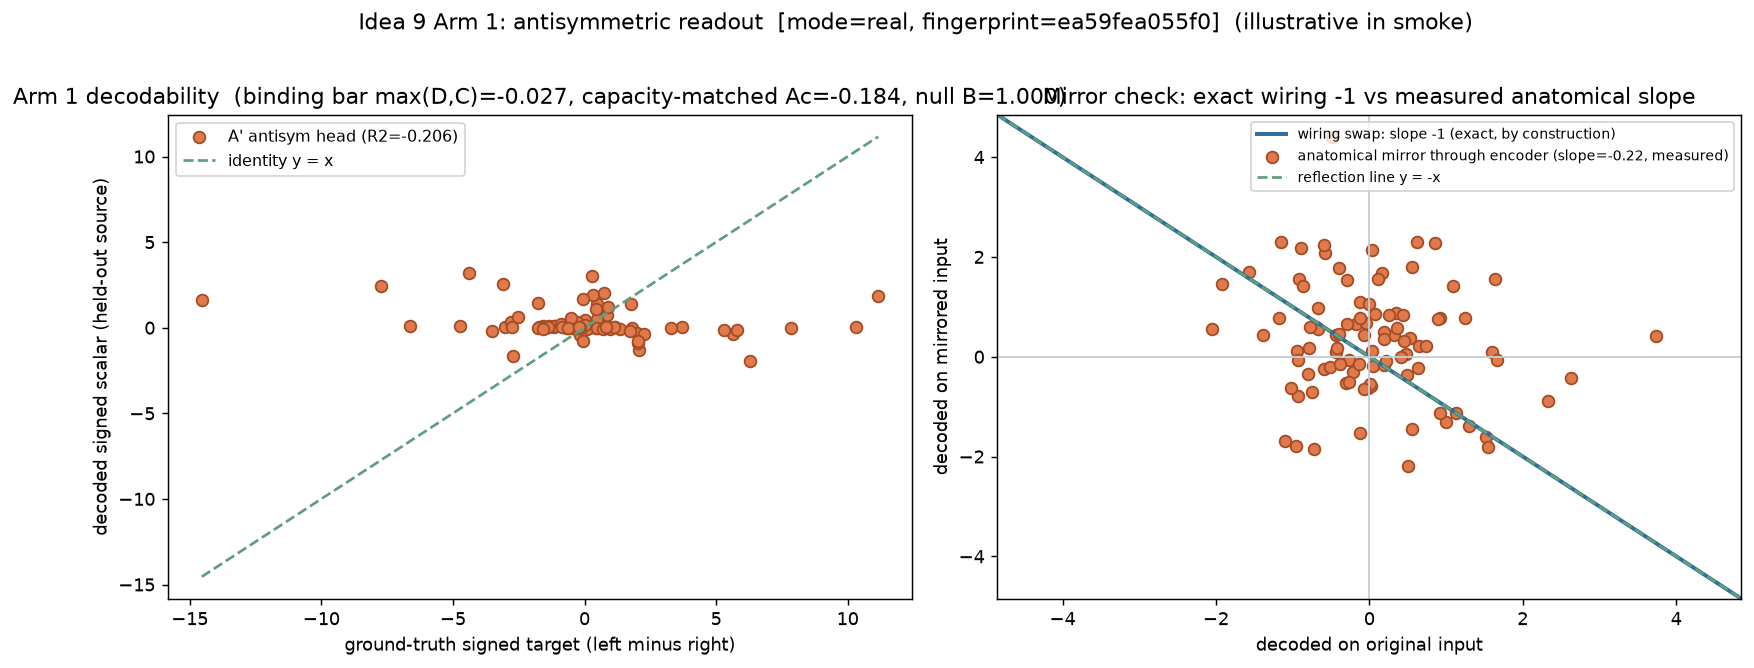

In [12]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

OUT_DIR = ARTIFACT_ROOT / MODE
OUT_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))

# Panel 1: decodability
if HAVE_TORCH:
    preds = lanes["A_prime"]["preds"]
    finite = preds[~np.isnan(preds)]
    ax[0].scatter(y, preds, s=42, c="#e07a4b", edgecolors="#a44c26",
                  label=f"A' antisym head (R2={lanes['A_prime']['r2']:.3f})")
    lo = float(min(y.min(), finite.min())); hi = float(max(y.max(), finite.max()))
    ax[0].plot([lo, hi], [lo, hi], "--", color="#5f9e7e", label="identity y = x")
    ax[0].set_title(
        f"Arm 1 decodability  (binding bar max(D,C)={max(lanes['D_standard']['r2'], lanes['C_floor']['r2']):.3f}, "
        f"capacity-matched Ac={lanes['Ac_capacity_matched']['r2']:.3f}, null B={lanes['B_raw_null']['r2']:.3f})")
else:
    ax[0].text(0.5, 0.5, "Learned lanes need PyTorch", ha="center")
ax[0].set_xlabel("ground-truth signed target (left minus right)")
ax[0].set_ylabel("decoded signed scalar (held-out source)")
ax[0].legend(loc="upper left", fontsize=9)

# Panel 2: mirror (two distinct series)
if mirror["available"]:
    do = mirror["dec_orig"]; dm = mirror["dec_mir"]
    lim = float(np.abs(np.concatenate([do, dm])).max()) * 1.1 + 1e-9
    # exact wiring identity: for illustration, plot the by-construction line s -> -s
    xs = np.linspace(-lim, lim, 50)
    ax[1].plot(xs, -xs, "-", color="#2f6f99", lw=2.2, label="wiring swap: slope -1 (exact, by construction)")
    ax[1].scatter(do, dm, s=42, c="#e07a4b", edgecolors="#a44c26",
                  label=f"anatomical mirror through encoder (slope={mirror['slope']:+.2f}, measured)")
    ax[1].plot([-lim, lim], [lim, -lim], "--", color="#5f9e7e", label="reflection line y = -x")
    ax[1].axhline(0, color="#c4cdd8", lw=1); ax[1].axvline(0, color="#c4cdd8", lw=1)
    ax[1].set_xlim(-lim, lim); ax[1].set_ylim(-lim, lim)
    ax[1].set_title("Mirror check: exact wiring -1 vs measured anatomical slope")
else:
    ax[1].text(0.5, 0.5, "Mirror needs the encoder", ha="center")
ax[1].set_xlabel("decoded on original input"); ax[1].set_ylabel("decoded on mirrored input")
ax[1].legend(loc="upper right", fontsize=8)

fig.suptitle(f"Idea 9 Arm 1: antisymmetric readout  [mode={MODE}, fingerprint={FINGERPRINT[:12]}]  (illustrative in smoke)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = OUT_DIR / "idea9_antisymmetric_readout_probe.png"
fig.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.close(fig)

# Reload the exact PNG written to disk so the inline panel and saved artifact
# cannot silently diverge. This also works with the non-interactive Agg backend.
from IPython.display import Image, display

print(f"saved figure: {fig_path}")
display(Image(filename=str(fig_path)))

## 12. Persist the result bundle

**Step 13 of 13.**

*What we are about to do.* Write one JSON bundle containing the verdict, per-lane R-squared and MAE, the
binding delta, the attribution delta, both permutation nulls, the exact wiring slope AND the measured
anatomical slope kept as separate fields, the y-variance decomposition, the fingerprint, the fold count
and manifest, the canonical-subset flag, and the cohort counts. Then reload the written bytes and display
the summary tables from THOSE bytes.

*Why the reload matters.* The displayed summary is generated from the saved file, so the inline tables
cannot drift from the machine-readable record that `IMPLEMENTATION.md`, the README, and `nb_09c` read.

*Why the fold manifest is included.* It records exactly which source videos were held out in each of the
5 folds. Without it, a later reader cannot check that folds really were source-disjoint, and the central
claim of the design would rest on trust.

*What to look at in the output, in order.*

1. `Artifact identity`: mode `real`, fingerprint `ea59fea055f0230b`, 96 sequences, 18 source videos, 5
   grouped folds, `canonical_only True`, `transductive True`, anatomical mirror slope -0.222906, mirror
   flips `False`. This table is the provenance of every other number.
2. `Per-lane held-out-source metrics`: the six-lane ladder again, rounded to 4 decimals.
3. `Pre-registered gate outcomes`: six rows, of which five read `False` and only `Exact wiring identity`
   reads `True`. Read this table as a list of escape routes CLOSED, not as a scorecard: the wiring pass is
   what makes the five failures interpretable rather than ambiguous.

*What this notebook established.* Three things, in ascending order of importance.

1. The antisymmetric-by-construction head was implemented correctly, with a swap slope of
   -1.0000000000000002, so nothing below can be blamed on a miswired readout.
2. Constraining the readout to be antisymmetric did NOT rescue Idea 5's null, and the resulting score is
   not admissible evidence about sides at all, because the side-blind lane E outscored the treatment by
   0.140. The verdict is `ARTIFACT (side-agnostic nuisance control fired)`, which is a WITHDRAWAL of the
   claim and therefore a weaker epistemic state than Idea 5's clean informative null.
3. The target itself cannot support this endpoint on this cohort: `y_between_source_fraction` = 0.0747
   against a preregistered 0.30, with 18 independent source videos. This measurement belongs to `nb_09a`,
   it explains both Idea 5's null and arm 1's artifact, and it is why arm 2 abandons R-squared as a
   primary endpoint.

*What remains open.* Whether side information exists in the representation under NONLINEAR readouts,
which was not tested. Whether an encoder trained to respect the mirror behaves differently, which arm 2
answers for the symmetry property itself (it can be driven to rho 0.0588, where 0 is mirror equivariant
and 4 is mirror blind) while still earning no credit because a preregistered guardrail regressed. And
whether any of this transfers, which needs a cohort with far more than 18 independent source videos.

*Where to go next.* `nb_09c` walks through the possible futures of these same hardened gates and holds
the external multi-view reach scaffold; note that its rehearsal predicted an informative null for arm 1
and did not anticipate the artifact. Arm 2's real path is `new_nb_09_00` through `new_nb_09_03`.


In [13]:
fold_manifest = []
if n_groups >= 2:
    gkf = GroupKFold(n_splits=n_splits)
    for i, (tr, te) in enumerate(gkf.split(np.zeros((len(y), 1)), y, groups)):
        fold_manifest.append({"fold": i,
                              "test_sources": sorted(set(groups[te].tolist())),
                              "n_test": int(len(te))})

bundle = {
    "notebook": "nb_09a_antisymmetric_readout_probe",
    "arm": "arm1_zero_retrain_readout",
    "mode": MODE,
    "fingerprint": FINGERPRINT,
    "n_sequences": int(len(records)),
    "n_sources": int(n_groups),
    "n_splits": int(n_splits),
    "head_out_dim": HEAD_OUT_DIM,
    "condition_counts": meta.groupby("condition").size().to_dict(),
    "lanes": {k: {"r2": v["r2"], "mae": v["mae"]} for k, v in lanes.items()},
    "binding_bar_max_D_C": verdict.get("binding_bar_max_D_C"),
    "binding_delta": verdict.get("binding_delta"),
    "attribution_delta_A_minus_Ac": verdict.get("attribution_delta_A_minus_Ac"),
    "permutation_null_A_prime": {k: perm_Aprime.get(k) for k in ("observed_r2", "null_mean", "null_p95", "p_value", "n_perm")},
    "permutation_null_C_floor": {**{k: perm_C.get(k) for k in ("observed_r2", "null_mean", "null_p95", "p_value", "n_perm")},
                                 "role": "floor characterization only (NOT a claim-withdrawing gate); a strong C is handled by the binding bar max(D,C)"},
    "wiring_identity": {"ok": bool(WIRING_IDENTITY_OK) if WIRING_IDENTITY_OK is not None else None,
                        "swap_slope": _slope},
    "lane_E_anatomically_invariant": verdict.get("E_anatomically_invariant_ok"),
    "anatomical_mirror": {"slope": mirror.get("slope"), "flips": mirror.get("flips")},
    "y_variance": {"between_source_fraction": y_between_fraction, "threshold": Y_BETWEEN_MIN, "ok": Y_GATE_OK},
    "canonical_subset_only": bool((meta["provenance"] == "canonical").all()),
    "fold_manifest": fold_manifest,
    "verdict": {k: v for k, v in verdict.items() if k != "preds"},
    "transductive": True,
    "notes": "All results transductive; source video is the independent unit; folder labels are dataset annotations, not diagnoses. The wiring-swap slope -1 is exact by construction; the anatomical-mirror slope is measured through the encoder and is not expected to be -1. Lane Ac is a capacity-matched control (same f/width/aggregation, adds the symmetric l+r path) so A'-vs-Ac isolates the antisymmetry constraint. Lane E is symmetrized over the anatomical mirror so E(x)==E(Mx). Lane C's permutation is floor characterization, not a leakage test.",
}
bundle_path = OUT_DIR / "idea9_antisymmetric_readout_result.json"
bundle_path.write_text(json.dumps(bundle, indent=2) + "\n", encoding="utf-8")

# Reload the machine-readable artifact before displaying it. The inline summary
# therefore reflects the exact JSON bytes that downstream notebooks will read.
saved_bundle = json.loads(bundle_path.read_text(encoding="utf-8"))
saved_verdict = saved_bundle["verdict"]

from IPython.display import Markdown, display

print(f"wrote {bundle_path}")
display(Markdown(
    "### Saved result summary\n\n"
    f"**Primary verdict:** {saved_verdict['PRIMARY_VERDICT']}\n\n"
    f"This is a **{saved_bundle['mode']}**, transductive analysis of "
    f"**{saved_bundle['n_sequences']} sequences** from "
    f"**{saved_bundle['n_sources']} source videos** using "
    f"**{saved_bundle['n_splits']} source-grouped folds**."
))

overview_table = pd.DataFrame([
    {
        "mode": saved_bundle["mode"],
        "fingerprint": saved_bundle["fingerprint"][:16],
        "sequences": saved_bundle["n_sequences"],
        "source_videos": saved_bundle["n_sources"],
        "grouped_folds": saved_bundle["n_splits"],
        "canonical_only": saved_bundle["canonical_subset_only"],
        "transductive": saved_bundle["transductive"],
        "anatomical_mirror_slope": saved_bundle["anatomical_mirror"]["slope"],
        "anatomical_mirror_flips": saved_bundle["anatomical_mirror"]["flips"],
    }
])

lane_table = (
    pd.DataFrame.from_dict(saved_bundle["lanes"], orient="index")
    .rename_axis("lane")
    .reset_index()
)
lane_table[["r2", "mae"]] = lane_table[["r2", "mae"]].round(4)

gate_table = pd.DataFrame([
    {
        "gate": "Beat binding bar",
        "observed": saved_verdict["binding_delta"],
        "requirement": ">= 0.05",
        "passed": saved_verdict["beats_binding_bar_by_0.05"],
    },
    {
        "gate": "Beat capacity-matched control",
        "observed": saved_verdict["attribution_delta_A_minus_Ac"],
        "requirement": ">= 0.05",
        "passed": saved_verdict["beats_capacity_matched_by_0.05"],
    },
    {
        "gate": "A-prime permutation",
        "observed": saved_verdict["A_prime_permutation_p"],
        "requirement": "p < 0.05",
        "passed": saved_verdict["A_prime_permutation_ok"],
    },
    {
        "gate": "Side-agnostic nuisance control",
        "observed": abs(saved_verdict["E_pooled_r2"]),
        "requirement": "abs(R2) < 0.05",
        "passed": saved_verdict["E_control_ok_abs"],
    },
    {
        "gate": "Between-source target variance",
        "observed": saved_verdict["y_between_source_fraction"],
        "requirement": f">= {saved_bundle['y_variance']['threshold']:.2f}",
        "passed": saved_verdict["y_quality_gate_ok"],
    },
    {
        "gate": "Exact wiring identity",
        "observed": saved_verdict["wiring_swap_slope"],
        "requirement": "slope = -1",
        "passed": saved_verdict["wiring_identity_ok"],
    },
])
gate_table["observed"] = gate_table["observed"].round(4)

print("Artifact identity")
display(overview_table)
print("Per-lane held-out-source metrics")
display(lane_table)
print("Pre-registered gate outcomes")
display(gate_table)

wrote /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/idea9_antisymmetric_readout_result.json


### Saved result summary

**Primary verdict:** ARTIFACT (side-agnostic nuisance control fired)

This is a **real**, transductive analysis of **96 sequences** from **18 source videos** using **5 source-grouped folds**.

Artifact identity


,mode,fingerprint,sequences,source_videos,grouped_folds,canonical_only,transductive,anatomical_mirror_slope,anatomical_mirror_flips
0,real,ea59fea055f0230b,96,18,5,True,True,-0.222906,False


Per-lane held-out-source metrics


,lane,r2,mae
0,B_raw_null,1.0000,0.0001
1,A_prime,-0.2057,2.0543
2,Ac_capacity_matched,-0.1839,2.0065
3,C_floor,-0.0270,1.8597
4,D_standard,-0.6022,2.4727
5,E_pooled,-0.0661,1.8995


Pre-registered gate outcomes


,gate,observed,requirement,passed
0,Beat binding bar,-0.1787,>= 0.05,False
1,Beat capacity-matched control,-0.0218,>= 0.05,False
2,A-prime permutation,0.9701,p < 0.05,False
3,Side-agnostic nuisance control,0.0661,abs(R2) < 0.05,False
4,Between-source target variance,0.0747,>= 0.30,False
5,Exact wiring identity,-1.0000,slope = -1,True


## Summary: what notebook 09a established, and what it did not

**The question.** Was Idea 5's null a readout-SHAPE problem? Would a head that is antisymmetric by
construction, so that exchanging left and right necessarily negates its output, recover a signed
laterality axis that Idea 5's unconstrained probe missed? No encoder weights were changed to find out.

**The answer.** No, and more precisely than "no". The verdict is
`ARTIFACT (side-agnostic nuisance control fired)`.

**The three numbers that carry it.**

1. The wiring identity holds at **-1.0000000000000002**, so the head really was antisymmetric and the
   outcome is not an implementation bug. This is what makes everything else interpretable.
2. The side-blind lane E scored **-0.066** against the antisymmetric treatment A_prime at **-0.206**, so
   a lane that mathematically cannot tell left from right beat the lane built to read left from right by
   **0.140**. A_prime's score therefore cannot be attributed to side information, which is what makes it
   an artifact rather than a null.
3. `y_between_source_fraction` = **0.0747** against a preregistered **0.30**. Only about 7.5 percent of
   the target's variance lies between the 18 source videos, so source-disjoint folds hold out nearly all
   of the usable signal by construction.

**Three verdicts that must not be collapsed into one.** Idea 5 returned an INFORMATIVE NULL: valid
measurement, answer no. Arm 1 returns an ARTIFACT: the lane is not admissible evidence about sides, so
the claim is WITHDRAWN rather than answered, which is a WEAKER epistemic state than a null and not a
stronger one. Arm 2 returns NO CREDIT: a real, large, consistent effect on 18 of 18 source videos, but a
preregistered guardrail failed and supplies a competing explanation.

**The escape routes this notebook closed.** Readout shape, ruled out here with a verified antisymmetric
head. Head capacity, ruled out by the capacity-matched lane Ac. Encoder contribution, ruled out by the
untrained floor lane C. Chance, ruled out by a 200-permutation null. Implementation error, ruled out by
the exact wiring identity. What is left is the cohort, which step 9 measured.

**What remains open.** Nonlinear readouts were not tested. Nothing here is clinical validation, nothing
is unseen-video performance, and every score is transductive because the encoder saw all 96 evaluation
sequences during training. Folder labels are dataset annotations, not diagnoses.

**Next.** `nb_09c` for the possible-futures rehearsal of these gates and the external reach scaffold;
`new_nb_09_00` through `new_nb_09_03` for arm 2, which trains the symmetry in rather than reading it out.
